In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import grangercausalitytests
import seaborn as sns



In [2]:
# Read in targets
targets_df = pd.read_csv('targets.csv')
targets_df['Date'] = pd.to_datetime(targets_df['Date'])
targets_df.set_index('Date', inplace=True)

# Read in predictors
predictors_df = pd.read_csv('predictors.csv')
predictors_df['Date'] = pd.to_datetime(predictors_df['Date'])
predictors_df.set_index('Date', inplace=True)

# Merge targets and predictors
merged_df = targets_df.join(predictors_df)
print(merged_df)

                     SO2    Auto Gas  Basic Chemicals    Fuel Oil  \
Date                                                                
1980-01-01  9.442626e-07   80.378294        86.835593   74.154677   
1980-04-01  9.340424e-07   74.045325        85.576519   66.056135   
1980-07-01  9.258992e-07   73.681244        80.152687   67.456106   
1980-10-01  9.199498e-07   73.421459        84.307597   70.289212   
1981-01-01  9.140747e-07   73.734122        86.152397   71.410456   
...                  ...         ...              ...         ...   
2022-10-01  3.424376e-07   98.531831        95.815294  102.555111   
2023-01-01  3.424159e-07   95.767037        99.619374   94.950619   
2023-04-01  3.424292e-07  101.908704        99.798314   99.925258   
2023-07-01  3.424477e-07  101.979881       100.576745  101.991806   
2023-10-01  3.424376e-07  100.344378       100.005567  103.132316   

            Manufacturing  Pave Roof PC  Petrol Coal  Total Population  \
Date                        

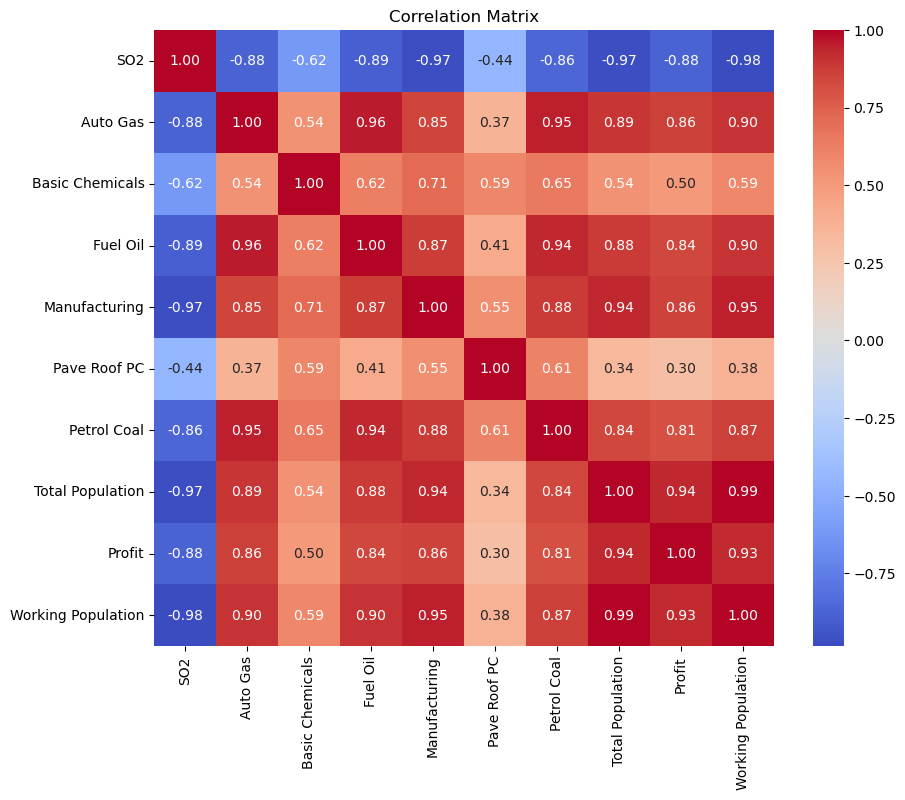

In [3]:
# Calculate correlation matrix
correlation_matrix = merged_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [4]:
# print(correlation_matrix)
# Features to include in analysis: 'Auto Gas', 'Manufacturing', 'Petrol Coal', 'Profit', 'Working Population'. 
# Given that the SO2 emissions are decreasing with increasing production index of industrial manufacturing sectors, corporate profit, and working population, 
# We now hypothesize that there are external factors that might be linked to the reduction of SO2 such as environmental regulation.
# We suggest that future work includes an analysis of environmental regulatory data in order to determine what role environmental protection efforts play in the results we presented here. 


# Let's drop all the unecessary features

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a new df with just the predictors of interest
selected_predictors = ['Auto Gas', 'Manufacturing', 'Petrol Coal', 'Profit', 'Working Population']
merged_df = merged_df[['SO2'] + selected_predictors]

# Calculate VIF for each predictor
predictors_df = merged_df[selected_predictors]
vif_data = pd.DataFrame()
vif_data["Feature"] = predictors_df.columns
vif_data["VIF"] = [variance_inflation_factor(predictors_df.values, i) for i in range(predictors_df.shape[1])]

# Display VIF values
print(vif_data)

              Feature         VIF
0            Auto Gas  794.855105
1       Manufacturing  106.664989
2         Petrol Coal  797.236141
3              Profit   25.961043
4  Working Population  342.922600


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# def perform_STL(df, feature):
#     # Perform STL decomposition
#     decomposition = seasonal_decompose(df[feature], model='multiplicative')

#     # Visualize the components
#     plt.figure(figsize=(10, 6))

#     plt.subplot(411)
#     plt.plot(decomposition.observed, label='Observed')
#     plt.legend(loc='upper left')

#     plt.subplot(412)
#     plt.plot(decomposition.trend, label='Trend')
#     plt.legend(loc='upper left')

#     plt.subplot(413)
#     plt.plot(decomposition.seasonal, label='Seasonal')
#     plt.legend(loc='upper left')

#     plt.subplot(414)
#     plt.plot(decomposition.resid, label='Residual')
#     plt.legend(loc='upper left')

#     plt.suptitle(f'STL Decomposition of {feature}')
#     plt.tight_layout()
#     plt.show()

def perform_multi_STL(df, features):
    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(20, 10))

    # Perform STL decomposition for each feature
    for feature in features:
        decomposition = seasonal_decompose(df[feature], model='multiplicative')

        # Plot observed
        axs[0].plot(decomposition.observed, label=feature)
        axs[0].set_title('Observed')
        axs[0].legend(loc='upper left')

        # Plot trend
        axs[1].plot(decomposition.trend, label=feature)
        axs[1].set_title('Trend')
        axs[1].legend(loc='upper left')

        # Plot seasonal
        axs[2].plot(decomposition.seasonal, label=feature)
        axs[2].set_title('Seasonal')
        axs[2].legend(loc='upper left')

        # Plot residual
        axs[3].plot(decomposition.resid, label=feature)
        axs[3].set_title('Residual')
        axs[3].legend(loc='upper left')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()


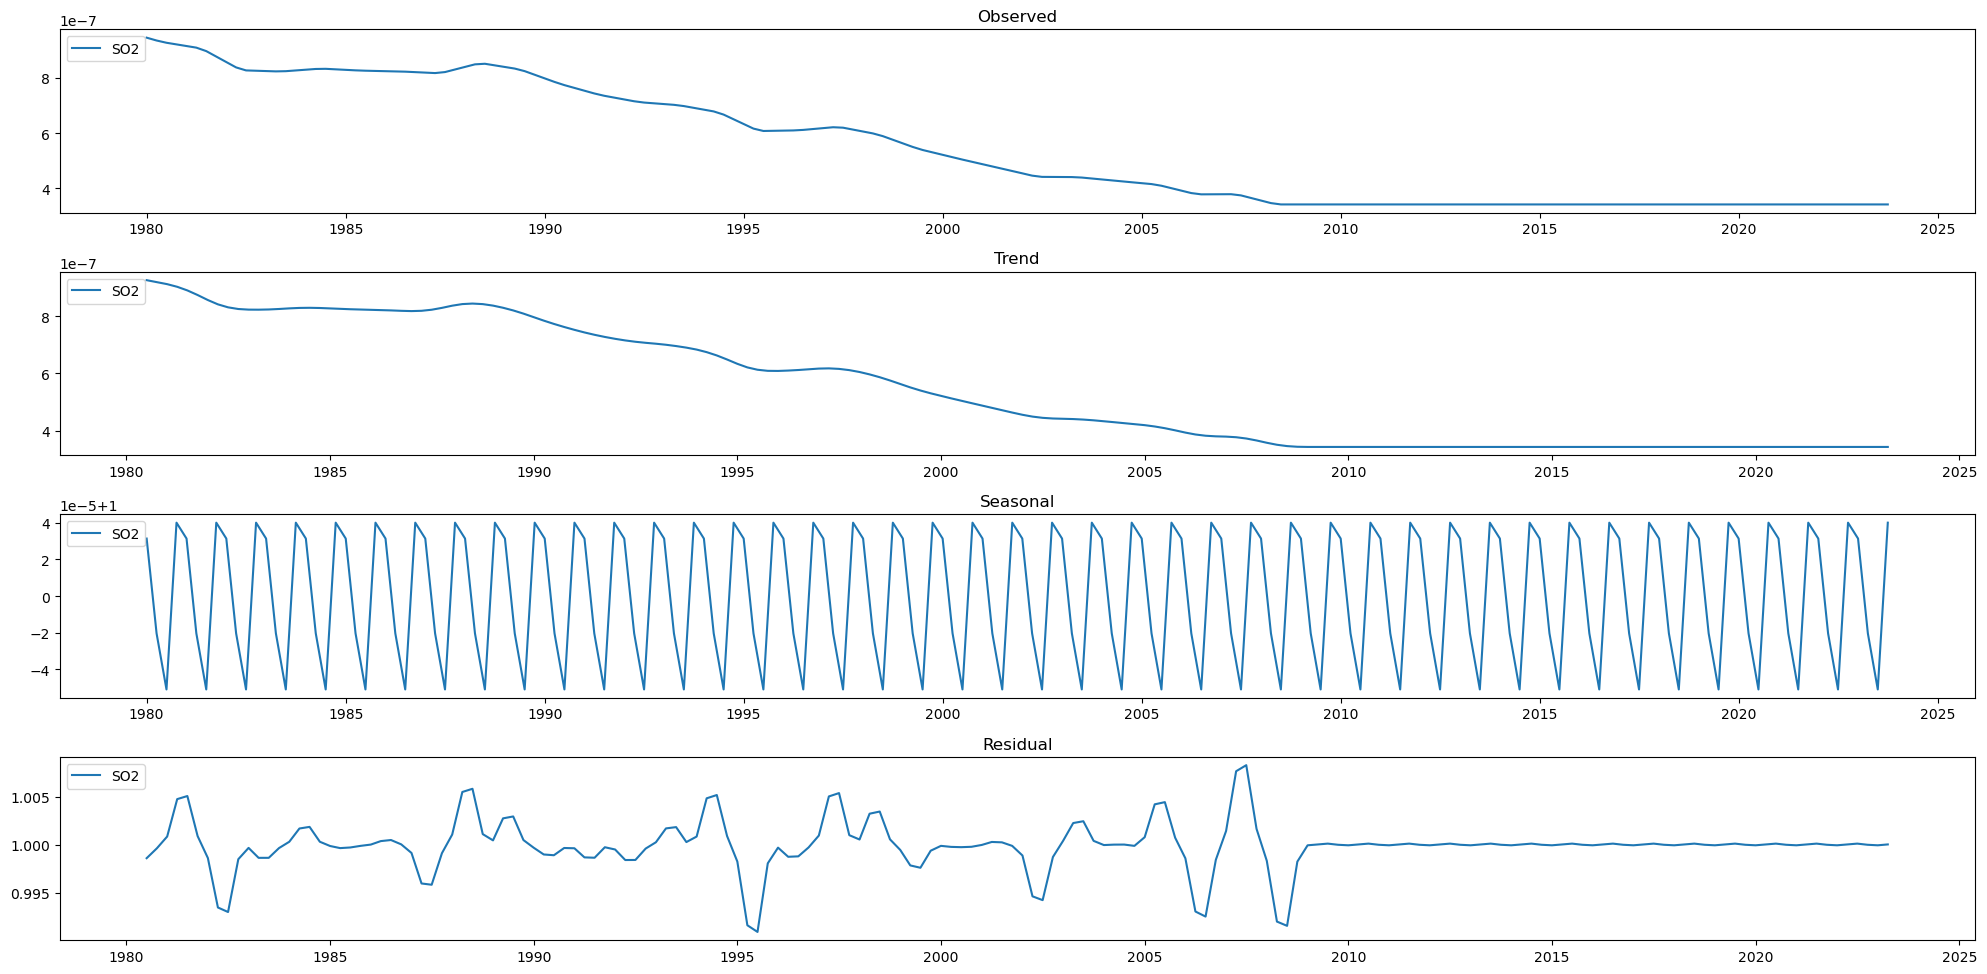

In [7]:
# perform_STL(merged_df, 'SO2')
perform_multi_STL(merged_df, ['SO2'])


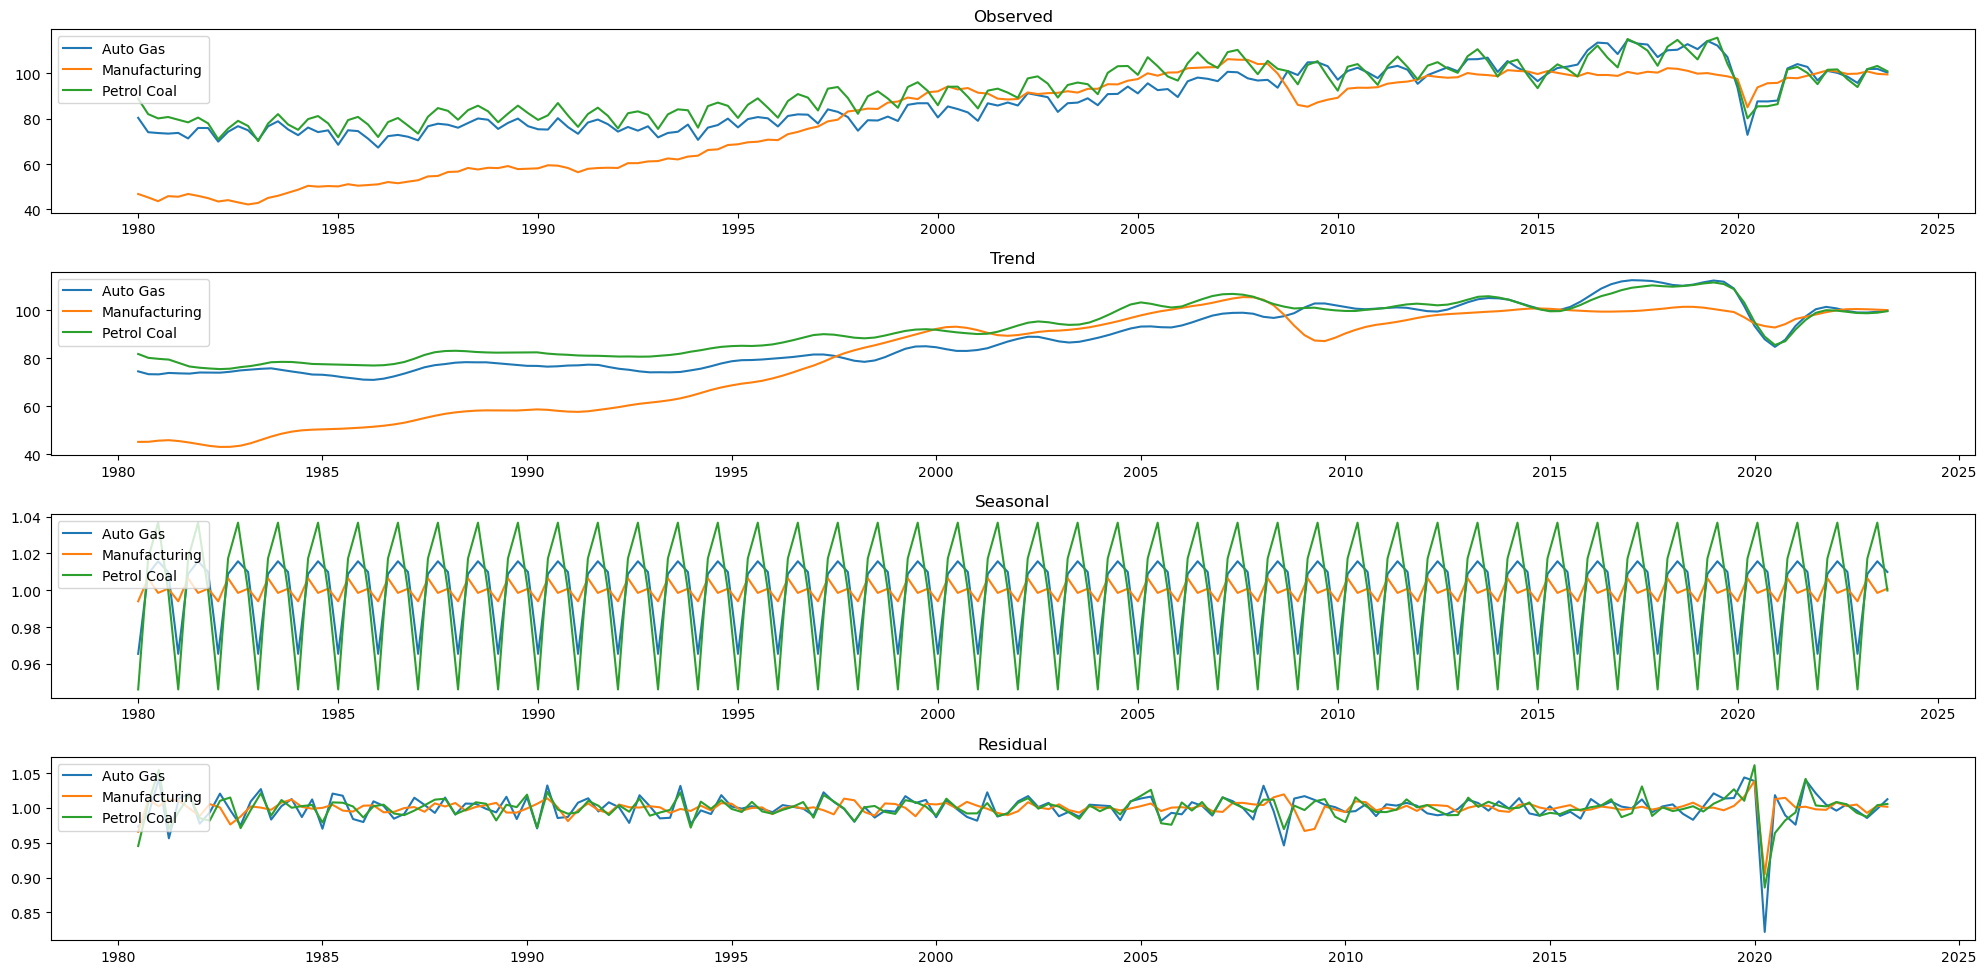

In [8]:
 # Call the function to perform STL decomposition and plot the selected predictors
perform_multi_STL(predictors_df, ['Auto Gas', 'Manufacturing', 'Petrol Coal'])  # maybe let's leave out fuel oil because it's pretty much the same as auto gas, but it appears to have a lag that I don't want to deal with. 


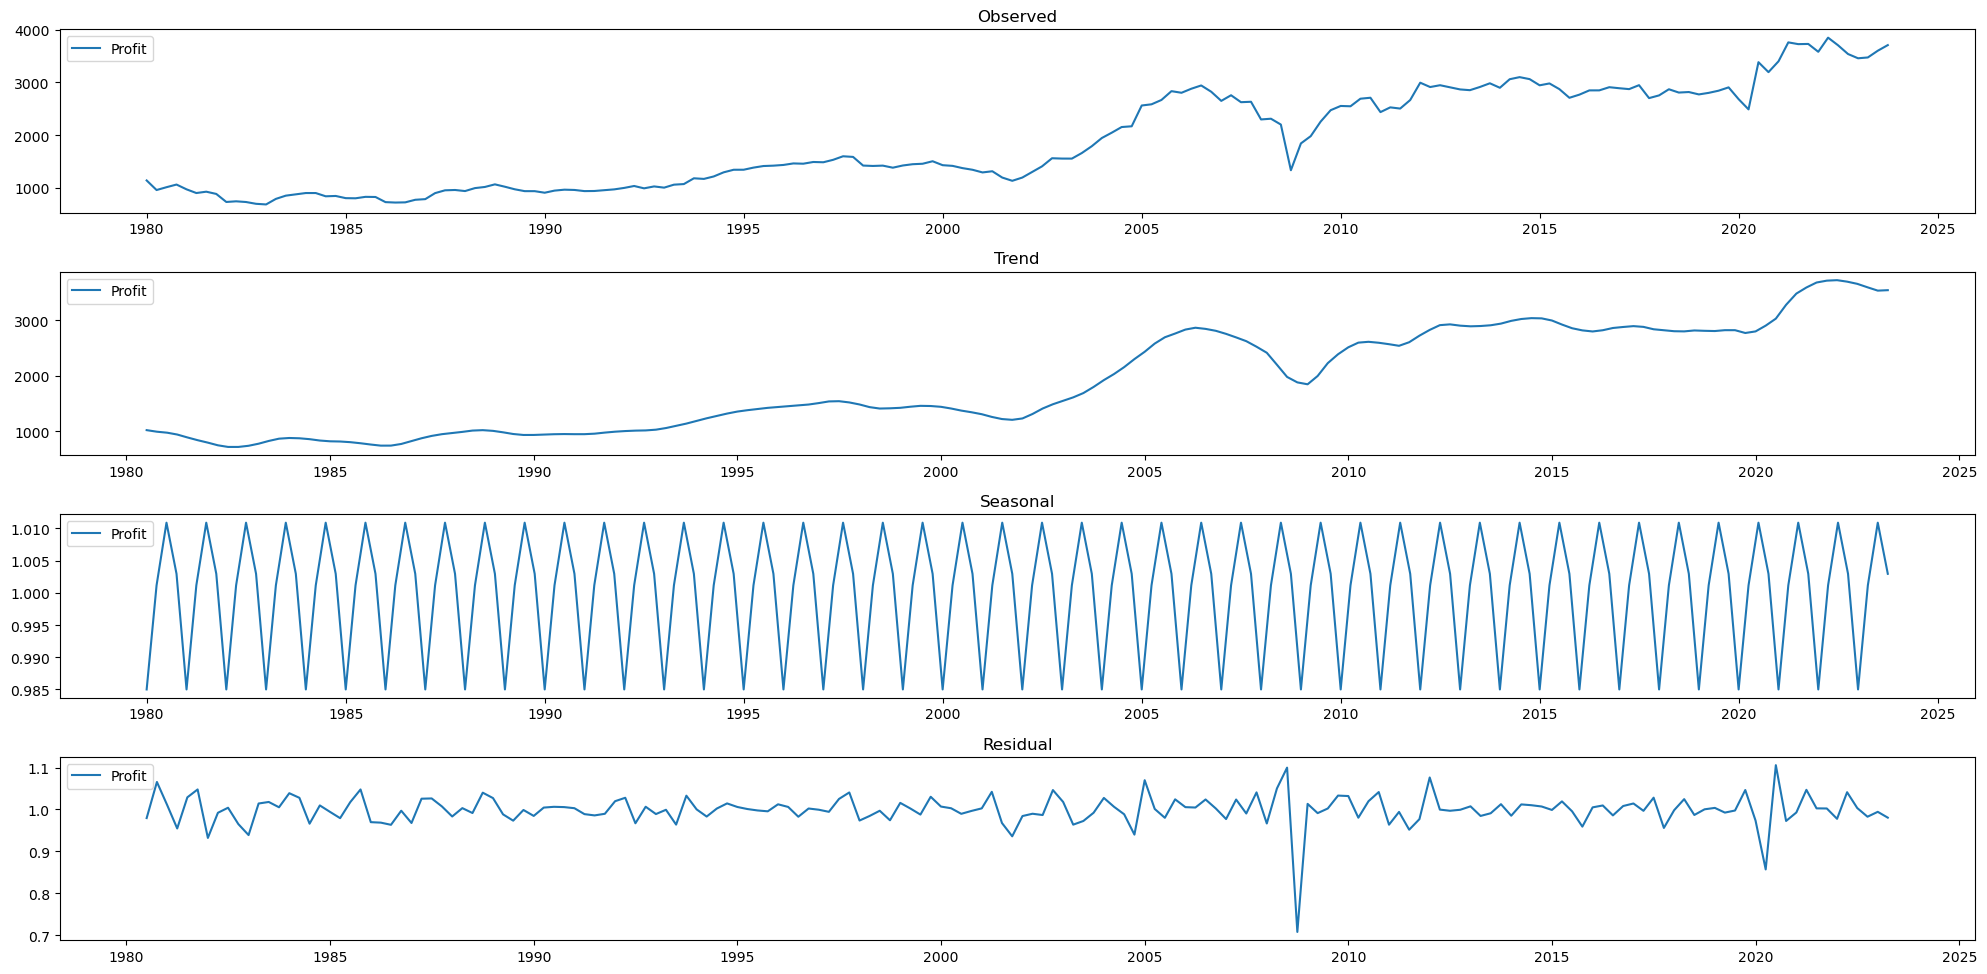

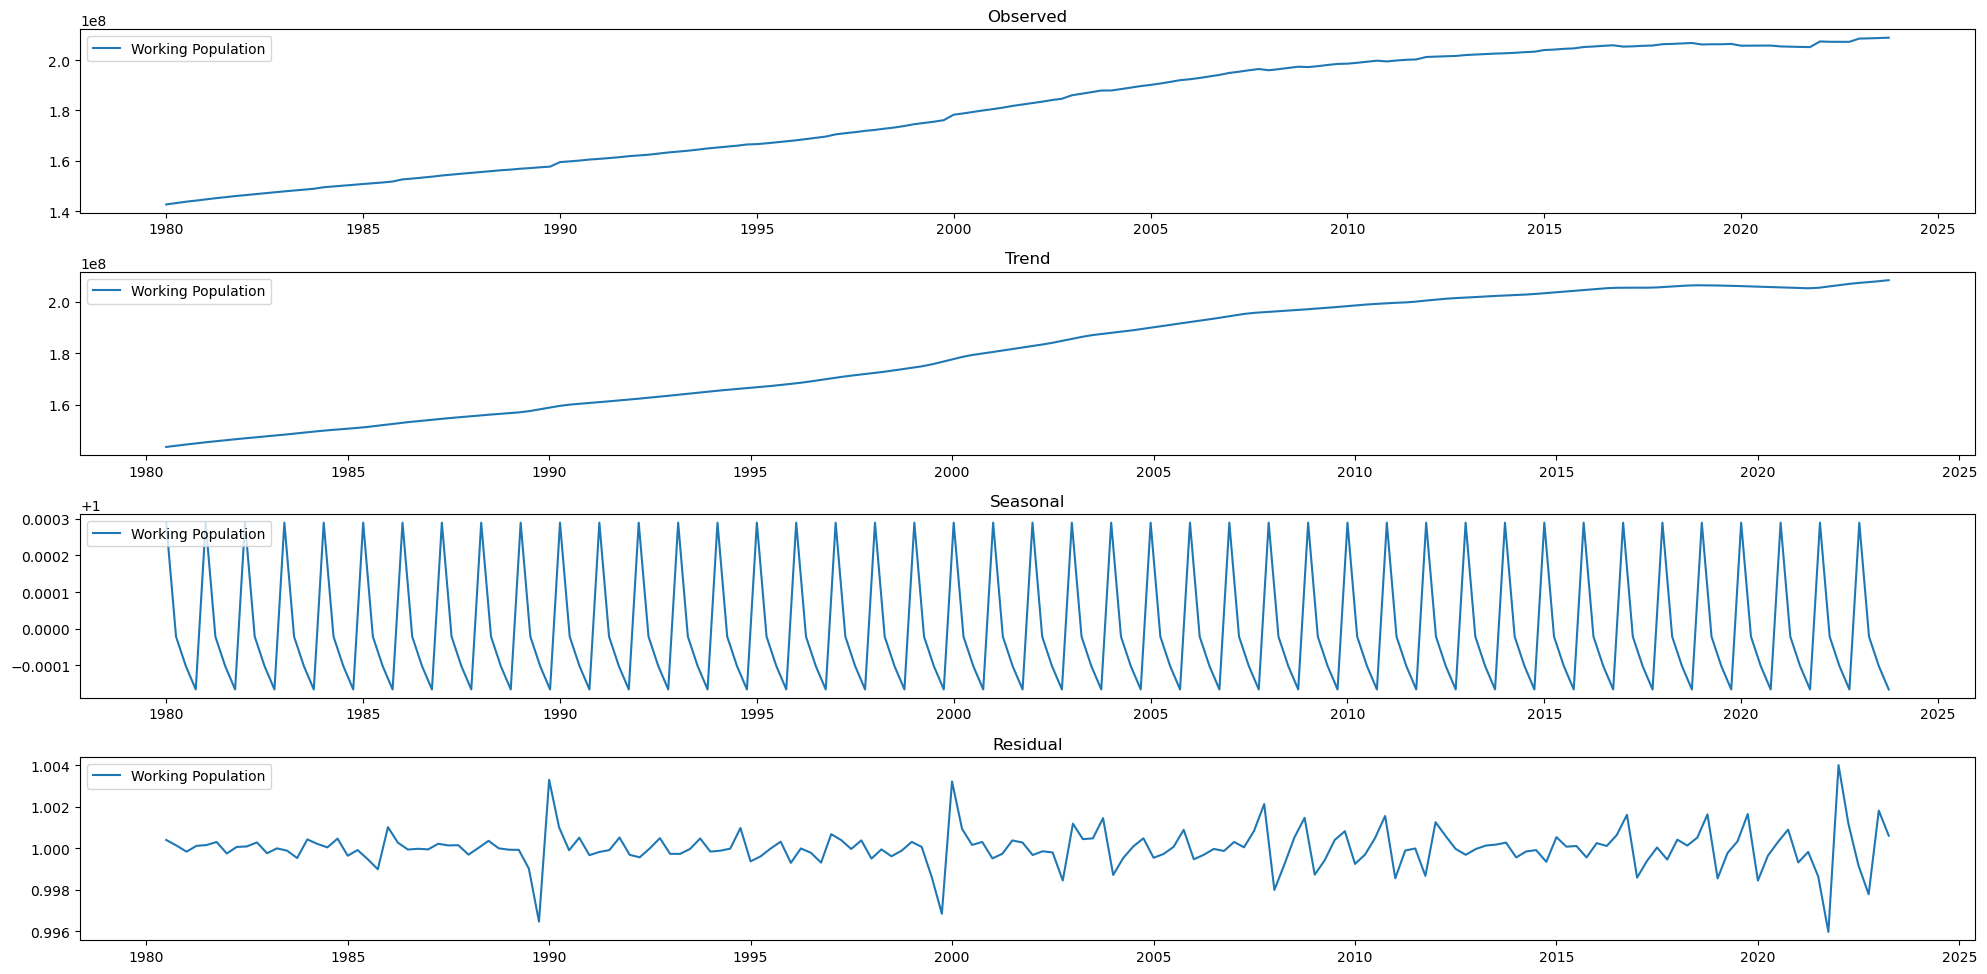

In [9]:
# Workers
perform_multi_STL(predictors_df, ['Profit'])              # Trend looks linear, but we used multiplicative for the sake of consistency (Profit and Working Pop both look linearish)
perform_multi_STL(predictors_df, ['Working Population'])  # Trend looks linear, but we used multiplicative for the sake of consistency


In [10]:

print(merged_df)




                     SO2    Auto Gas  Manufacturing  Petrol Coal       Profit  \
Date                                                                            
1980-01-01  9.442626e-07   80.378294      46.805149    88.803466  1141.031335   
1980-04-01  9.340424e-07   74.045325      45.293618    82.028254   959.105013   
1980-07-01  9.258992e-07   73.681244      43.621773    80.131477  1012.712596   
1980-10-01  9.199498e-07   73.421459      45.854066    80.748748  1063.103059   
1981-01-01  9.140747e-07   73.734122      45.590844    79.559832   972.401627   
...                  ...         ...            ...          ...          ...   
2022-10-01  3.424376e-07   98.531831      99.729927    97.423327  3538.278898   
2023-01-01  3.424159e-07   95.767037      99.867739    93.966345  3457.564000   
2023-04-01  3.424292e-07  101.908704     100.835622   101.857295  3473.110000   
2023-07-01  3.424477e-07  101.979881      99.776331   103.262438  3600.621000   
2023-10-01  3.424376e-07  10

In [11]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import train_test_split

# # Step 1: Separate target variable and predictors
# X = merged_df.drop(columns=['SO2'])
# y = merged_df['SO2']

# # Step 2: Standardize predictors
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Step 3: Apply Ridge regularization
# ridge = Ridge(alpha=1.0)  # You can adjust the regularization strength (alpha) as needed
# ridge.fit(X_scaled, y)

# # Step 4: Evaluate the model (optional)
# # For example, you can check the coefficients of the Ridge model
# print("Ridge Coefficients:", ridge.coef_)


In [12]:
# from statsmodels.graphics.tsaplots import plot_acf

# # Plot autocorrelation function (ACF)
# plot_acf(merged_df['SO2'], lags=40)
# plt.xlabel('Lag')
# plt.ylabel('Autocorrelation')
# plt.title('Autocorrelation Function (ACF)')
# plt.show()


In [13]:
# # Generate scatter plots
# plt.figure(figsize=(12, 8))

# plt.subplot(2, 3, 1)
# plt.scatter(merged_df['Auto Gas'], merged_df['SO2'], color='blue', alpha=0.5)
# plt.xlabel('Auto Gas')
# plt.ylabel('SO2')
# plt.title('Auto Gas vs SO2')

# plt.subplot(2, 3, 2)
# plt.scatter(merged_df['Manufacturing'], merged_df['SO2'], color='green', alpha=0.5)
# plt.xlabel('Manufacturing')
# plt.ylabel('SO2')
# plt.title('Manufacturing vs SO2')

# plt.subplot(2, 3, 3)
# plt.scatter(merged_df['Petrol Coal'], merged_df['SO2'], color='red', alpha=0.5)
# plt.xlabel('Petrol Coal')
# plt.ylabel('SO2')
# plt.title('Petrol Coal vs SO2')

# plt.subplot(2, 3, 4)
# plt.scatter(merged_df['Profit'], merged_df['SO2'], color='orange', alpha=0.5)
# plt.xlabel('Profit')
# plt.ylabel('SO2')
# plt.title('Profit vs SO2')

# plt.subplot(2, 3, 5)
# plt.scatter(merged_df['Working Population'], merged_df['SO2'], color='purple', alpha=0.5)
# plt.xlabel('Working Population')
# plt.ylabel('SO2')
# plt.title('Working Population vs SO2')

# plt.tight_layout()
# plt.show()


In [14]:
# # Define the lag periods
# lags = [1, 2, 3, 4]  # you can adjust the lag periods as needed

# # Create lagged variables for each feature
# for lag in lags:
#     merged_df[f'Auto Gas_lag_{lag}'] = merged_df['Auto Gas'].shift(lag)
#     merged_df[f'Manufacturing_lag_{lag}'] = merged_df['Manufacturing'].shift(lag)
#     merged_df[f'Petrol Coal_lag_{lag}'] = merged_df['Petrol Coal'].shift(lag)
#     merged_df[f'Profit_lag_{lag}'] = merged_df['Profit'].shift(lag)
#     merged_df[f'Working Population_lag_{lag}'] = merged_df['Working Population'].shift(lag)

# # # Drop rows with NaN values introduced by the shifting
# # merged_df.dropna(inplace=True)
# # Compute correlation matrix
# lagged_correlation_matrix = merged_df.corr()

# # Display correlation matrix
# # print(lagged_correlation_matrix['SO2'])

# # Plot correlation heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(lagged_correlation_matrix[['SO2']], annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Correlation Heatmap between Lagged Variables and SO2')
# plt.show()


# Modeling: Only historical SO2

In [15]:
import itertools
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np



def time_series_train_test_split(data, split_date):
    train_data = data[data.index < split_date]
    test_data = data[data.index >= split_date]
    return train_data, test_data

def find_best_arima_params_cv(train_data, cv_folds=5):
    p_range = range(0, 3)
    d_range = range(0, 2)
    q_range = range(0, 3)
    param_combinations = list(itertools.product(p_range, d_range, q_range))
    best_params = None
    best_rmse = float('inf')
    tscv = TimeSeriesSplit(n_splits=cv_folds)
    
    for params in param_combinations:
        total_rmse = 0
        for train_index, test_index in tscv.split(train_data):
            train_fold, test_fold = train_data.iloc[train_index], train_data.iloc[test_index]
            p, d, q = params
            try:
                model = SARIMAX(train_fold, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False)
                fitted_model = model.fit(disp=False)
                forecast = fitted_model.forecast(steps=len(test_fold))
                rmse = np.sqrt(np.mean((forecast - test_fold) ** 2))
                total_rmse += rmse
            except:
                continue
        avg_rmse = total_rmse / cv_folds
        
        if avg_rmse < best_rmse:
            best_params = params
            best_rmse = avg_rmse
    return best_params, best_rmse



def tune_alpha_ses(train_data, cv_folds=5):

    alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5]

    # Initialize variables to store the best alpha and corresponding RMSE
    best_alpha = None
    best_rmse = float('inf')    
    tscv = TimeSeriesSplit(n_splits=cv_folds)
    # Perform time-series cross-validation for each alpha value
    for alpha in alpha_values:
        total_rmse = 0
        # Iterate over each fold for cross-validation
        for train_index, test_index in tscv.split(train_data):
            train_fold, test_fold = train_data[train_index], train_data[test_index]
            ses_model = SimpleExpSmoothing(train_fold)
            fitted_ses_model = ses_model.fit(smoothing_level=alpha)
            forecast = fitted_ses_model.forecast(len(test_fold))
            fold_rmse = np.sqrt(mean_squared_error(test_fold, forecast))
            total_rmse += fold_rmse
        
        # Calculate average RMSE across all folds for the current alpha
        avg_rmse = total_rmse / cv_folds
        
        # Update best alpha if the current one has lower RMSE
        if avg_rmse < best_rmse:
            best_alpha = alpha
            best_rmse = avg_rmse
    
    return best_alpha, best_rmse



def evaluate_model_metrics(train_data, test_data, tuned_params, model_name):
    if model_name == 'SARIMA':
        model = SARIMAX(train_data, order=tuned_params, enforce_stationarity=False, enforce_invertibility=False)
        fitted_model = model.fit(disp=False)
    elif model_name == 'SES':
        model = SimpleExpSmoothing(train_data) 
        fitted_model = model.fit(smoothing_level=tuned_params)


    forecast = fitted_model.forecast(steps=len(test_data))
    mae = mean_absolute_error(test_data, forecast)
    rmse = np.sqrt(mean_squared_error(test_data, forecast))
    mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
    mase = np.mean(np.abs(test_data - forecast)) / np.mean(np.abs(test_data.diff().dropna()))
    return mae, rmse, mape, mase, forecast  # returning forecasted values as well


def evaluate_exmodel_metrics(train_data, test_data, exog_train, exog_test, order):
    model = SARIMAX(train_data, exog=exog_train, order=order, enforce_stationarity=False, enforce_invertibility=False)
    fitted_model = model.fit(disp=False)
    forecast = fitted_model.forecast(steps=len(test_data), exog=exog_test)

    mae = mean_absolute_error(test_data, forecast)
    rmse = np.sqrt(mean_squared_error(test_data, forecast))
    mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100
    mase = np.mean(np.abs(test_data - forecast)) / np.mean(np.abs(test_data.diff().dropna()))
    return mae, rmse, mape, mase, forecast






In [16]:
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.holtwinters import SimpleExpSmoothing


# Define the range of differencing orders to try
max_diff_order = 100 

for i in range(1, max_diff_order + 1):  # Start from 1 to avoid differencing with zero periods
    data_diff = merged_df['SO2'].diff(periods=i).dropna()

    dftest = ts.adfuller(data_diff, autolag='AIC')
    print(f"Differencing Order: {i}")
    print("ADF Statistic:", dftest[0])
    print("p-value:", dftest[1])
    
    if dftest[1] <= 0.05:
        print(f"Stationary at differencing order {i}")
        break  # Exit loop once stationary


def detrend_data(df, features):
    detrended_df = pd.DataFrame(index=df.index)  # Create an empty DataFrame to store detrended data
    
    for feature in features:
        decomposition = seasonal_decompose(df[feature], model='multiplicative', extrapolate_trend='freq')
        detrended_df[feature] = df[feature] - decomposition.trend
    
    return detrended_df

# Detrend each column in merged_df



Differencing Order: 1
ADF Statistic: -1.8109693285547068
p-value: 0.3750294863057696
Differencing Order: 2
ADF Statistic: -1.770602570078287
p-value: 0.39515124707825594
Differencing Order: 3
ADF Statistic: -1.5759638838773118
p-value: 0.4956553764517644
Differencing Order: 4
ADF Statistic: -1.601729142517058
p-value: 0.4827248073622845
Differencing Order: 5
ADF Statistic: -1.6261518489173046
p-value: 0.46950562296217846
Differencing Order: 6
ADF Statistic: -1.7569155282661657
p-value: 0.4020518294727689
Differencing Order: 7
ADF Statistic: -1.6095463339661915
p-value: 0.4787964942908776
Differencing Order: 8
ADF Statistic: -1.5431787119982523
p-value: 0.512053689534282
Differencing Order: 9
ADF Statistic: -1.8070810920017115
p-value: 0.3769518383623728
Differencing Order: 10
ADF Statistic: -1.8961828288042901
p-value: 0.3338589538836023
Differencing Order: 11
ADF Statistic: -1.704284925716789
p-value: 0.4289061175230737
Differencing Order: 12
ADF Statistic: -1.7076951121094357
p-value

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def forecast_data(model_name, original_df, cutoff_date = '2015-01-01', truncate = False):   # 2015 or 2003 if you truncate it. 

    if model_name == 'SARIMAX':
        # standardize data
        # Perform PCA
        # Scree plot to determine how many principle components
        # 
        

#-------------------------
        detrended_df = detrend_data(original_df, original_df.columns)
        
        # Extract exogenous variables
        exogenous_vars = merged_df.drop(columns=['SO2'])

        # Only use the training data for the exogeneous variables... train test split for SARIMAX ONLY
        detrended_df_train = detrended_df.loc[detrended_df.index < cutoff_date]
        detrended_df_test = detrended_df.loc[detrended_df.index >= cutoff_date]
        exogenous_vars_train = exogenous_vars.loc[exogenous_vars.index < cutoff_date]
        exogenous_vars_test = exogenous_vars.loc[exogenous_vars.index >= cutoff_date]       # never use this


        # Standardize the data
        scaler = StandardScaler()
        exogenous_vars_scaled = scaler.fit_transform(exogenous_vars_train)

        # Perform PCA
        pca = PCA()
        principal_components = pca.fit_transform(exogenous_vars_scaled)


        # Plot scree plot
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o', linestyle='-')
        plt.title('Scree Plot')
        plt.xlabel('Principal Component')
        plt.ylabel('Explained Variance Ratio')
        plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
        plt.grid(True)
        plt.show()

        
        # Create a dataframe for the principal components
        principal_df = pd.DataFrame(data=principal_components, index=exogenous_vars_train.index,
                                    columns=[f'PC{i}' for i in range(1, len(exogenous_vars_train.columns)+1)])

        
        # print(merged_df)
        print('FUCK YOU')
        print(principal_df)                         # this is the full PC dataframe
        PC1 = principal_df[['PC1']].copy()          # this is your exogeneous training data
        print(PC1)



        
        # Look at loadings to see what is being thrown out


        # Concatenate with SO2 data ... this should only include data for PC1 until 2008            ---> This is now the training SO2 data, and the training PCA1. Only PCA1 because others don't matter much (as seen in Scree Plot)
        # scaled_df = pd.concat([principal_df['PC1'], detrended_df.loc[principal_df.index, 'SO2']], axis=1)
        




        # Print the explained variance ratio
        print("Explained Variance Ratio:", pca.explained_variance_ratio_)

        



#-------------------------


        # if not using exogeneous variables, 
    else:
        detrended_df = detrend_data(original_df, original_df.columns)

    # Truncate data to leave out flat part
    if truncate == True:
        detrended_df.index = pd.to_datetime(detrended_df.index)
        detrended_df = detrended_df.loc[detrended_df.index < '2008-01-01']

    # Split data into training and test sets
    train_data, test_data = time_series_train_test_split(detrended_df, cutoff_date)
    SO2_train = train_data['SO2']
    SO2_test = test_data['SO2']

    # Define exogeneous variables for all models, but we don't use them unless it's SARIMAX
    exog_train = merged_df.drop(columns=['SO2']).loc[train_data.index]
    exog_test = merged_df.drop(columns=['SO2']).loc[test_data.index]

    if model_name == 'SARIMA':
        best_params, best_rmse = find_best_arima_params_cv(SO2_train)
        mae, rmse, mape, mase, forecast = evaluate_model_metrics(SO2_train, SO2_test, best_params, model_name)

    elif model_name == 'SARIMAX':
        best_params, best_rmse = find_best_arima_params_cv(SO2_train) # --> shouldn't this use SO2_train and exogeneous variables?
        mae, rmse, mape, mase, forecast = evaluate_exmodel_metrics(SO2_train, SO2_test, exog_train, exog_test, best_params)

    elif model_name == 'SES':
        best_params, best_rmse = tune_alpha_ses(SO2_train)
        mae, rmse, mape, mase, forecast = evaluate_model_metrics(SO2_train, SO2_test, best_params, model_name)

    




    # Plotting entire time series and forecasted line
    plt.figure(figsize=(12, 8))

    # Subplot for entire time series
    plt.subplot(2, 1, 1)
    plt.plot(detrended_df.index, detrended_df['SO2'], label='SO2')
    plt.plot(SO2_test.index, forecast, color='red', linestyle='--', label='Forecasted SO2')
    plt.title('Original Time Series and Forecasted Line')
    plt.xlabel('Date')
    plt.ylabel('SO2')
    plt.legend()
    plt.grid(True)

    # Subplot for forecasted range
    plt.subplot(2, 1, 2)
    plt.plot(SO2_test.index, SO2_test, label='SO2')
    plt.plot(SO2_test.index, forecast, color='red', linestyle='--', label='Forecasted SO2')
    plt.title('Original Time Series and Forecasted Line')
    plt.xlabel('Date')
    plt.ylabel('SO2')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/b

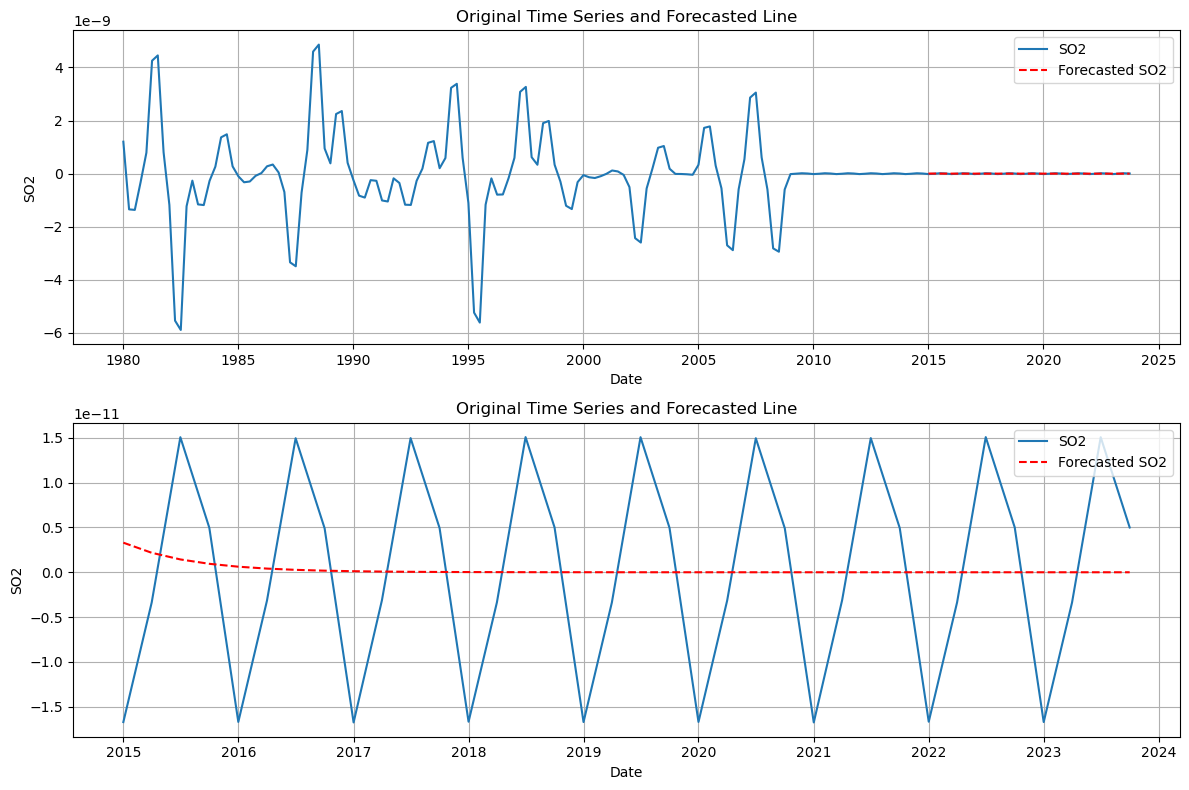

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/b

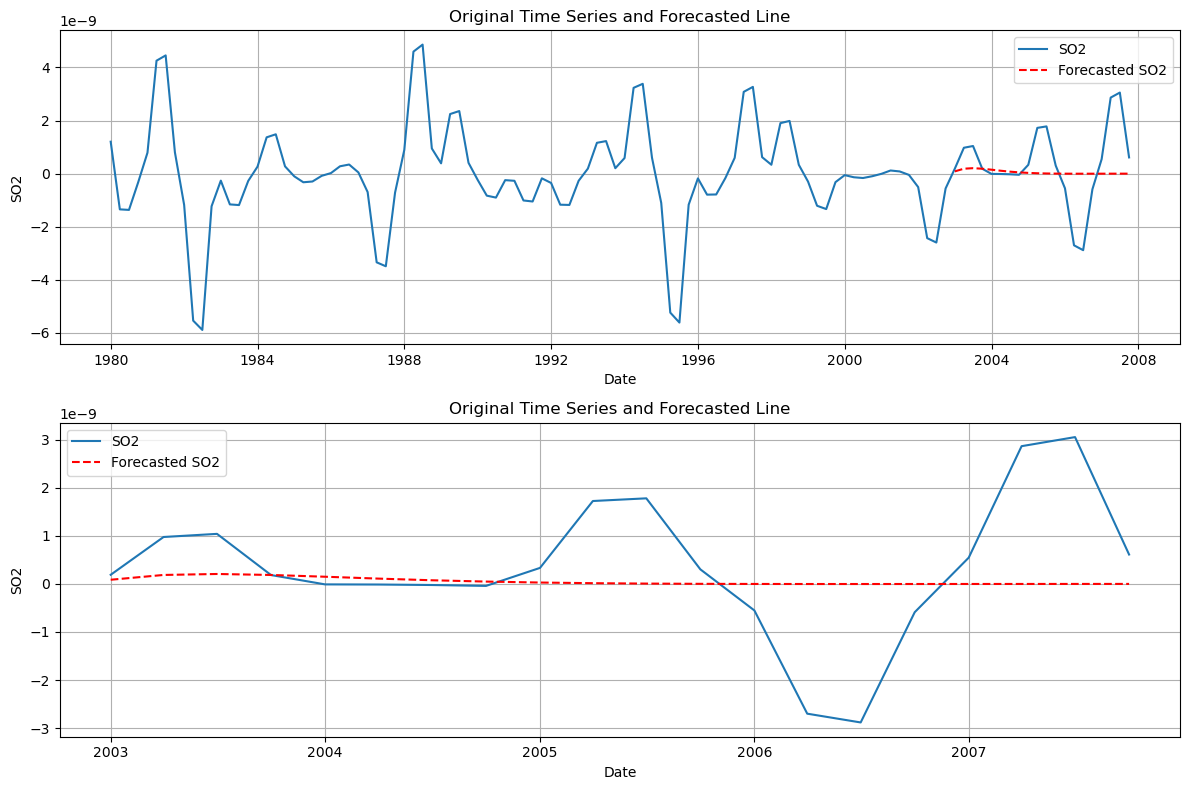

In [18]:
forecast_data('SARIMA', merged_df, cutoff_date = '2015-01-01', truncate = False)
forecast_data('SARIMA', merged_df, cutoff_date = '2003-01-01', truncate = True)   


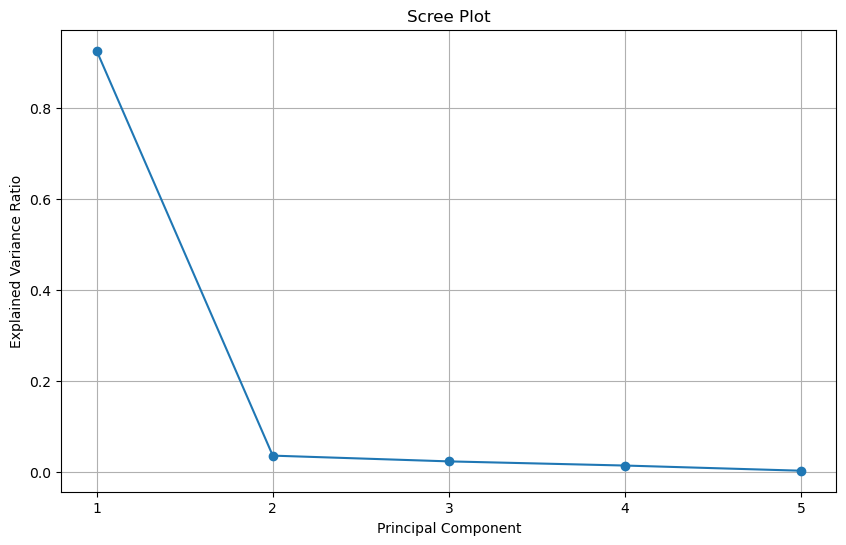

FUCK YOU
                 PC1       PC2       PC3       PC4       PC5
Date                                                        
1980-01-01 -1.830782 -1.078558  0.478363 -0.560457 -0.130459
1980-04-01 -2.512067 -0.636798  0.114222 -0.398237 -0.028616
1980-07-01 -2.599944 -0.662497 -0.060428 -0.310108 -0.024317
1980-10-01 -2.495918 -0.600919 -0.084161 -0.385536 -0.031575
1981-01-01 -2.581748 -0.551606 -0.055143 -0.252586 -0.063009
...              ...       ...       ...       ...       ...
2013-10-01  3.624117 -0.645289 -0.138165  0.207082 -0.123539
2014-01-01  3.005618 -0.217888 -0.604806  0.315031 -0.070465
2014-04-01  3.626670 -0.520255 -0.298669  0.130652 -0.129538
2014-07-01  3.584139 -0.442879 -0.343935 -0.079823  0.063242
2014-10-01  3.177782 -0.213276 -0.744903  0.197836 -0.074526

[140 rows x 5 columns]
                 PC1
Date                
1980-01-01 -1.830782
1980-04-01 -2.512067
1980-07-01 -2.599944
1980-10-01 -2.495918
1981-01-01 -2.581748
...              ...
2013-1

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/b

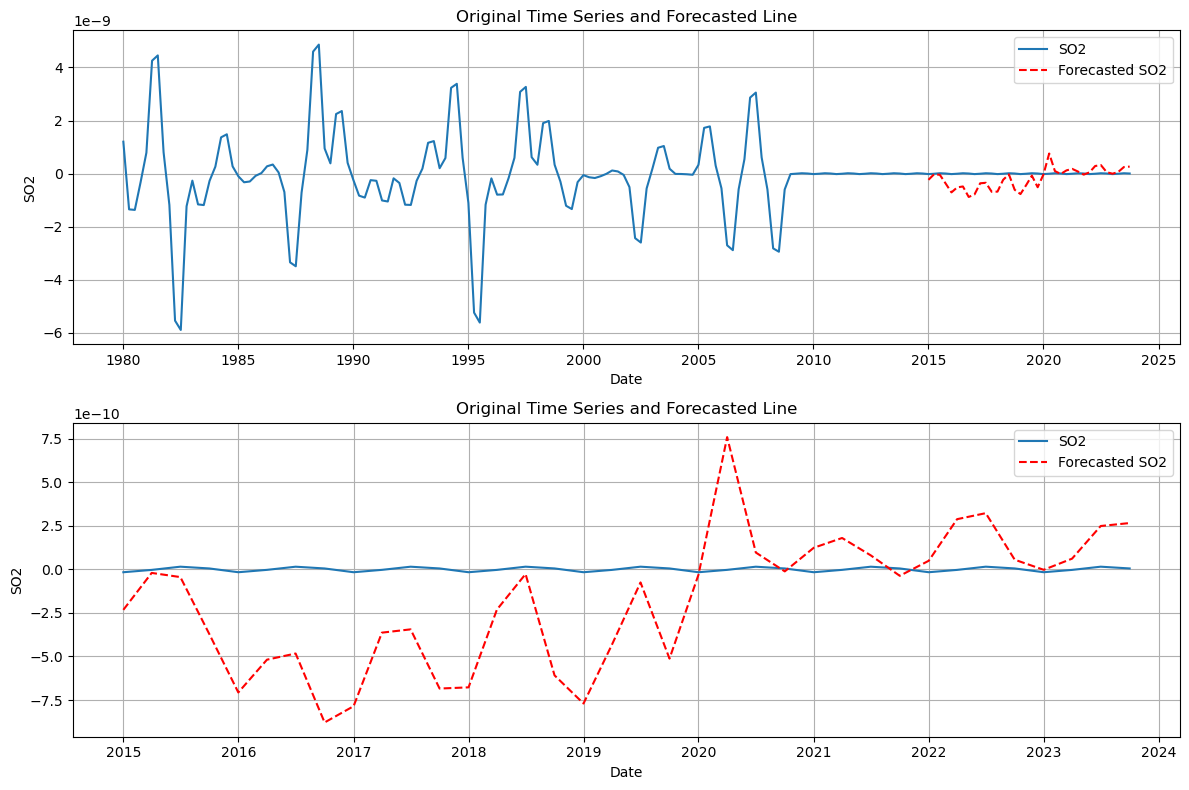

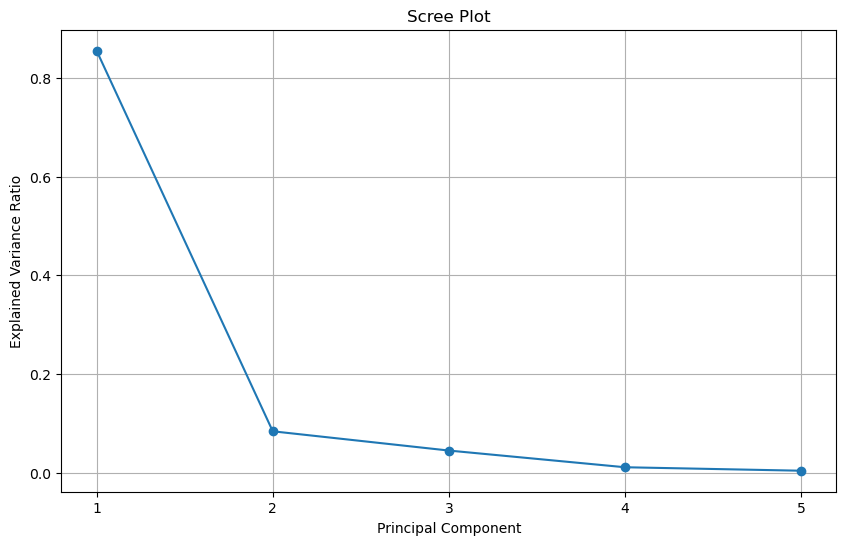

FUCK YOU
                 PC1       PC2       PC3       PC4       PC5
Date                                                        
1980-01-01 -0.574353  1.703764 -1.266824  0.080099  0.138254
1980-04-01 -1.943160  0.648012 -0.754380  0.287815  0.148121
1980-07-01 -2.047428  0.404113 -0.886487  0.055745  0.050548
1980-10-01 -1.860521  0.292010 -1.009913  0.130643  0.099599
1981-01-01 -2.057760  0.343508 -0.673650  0.038074  0.117506
...              ...       ...       ...       ...       ...
2001-10-01  2.946086  0.494676  1.280556 -0.130111 -0.025363
2002-01-01  2.798030  0.053517  1.134345 -0.276100 -0.042317
2002-04-01  4.167017  1.167043  0.844768 -0.080112 -0.061768
2002-07-01  4.338339  0.987543  0.478166  0.029128 -0.194478
2002-10-01  4.320753  0.404669  0.088711 -0.360060 -0.211121

[92 rows x 5 columns]
                 PC1
Date                
1980-01-01 -0.574353
1980-04-01 -1.943160
1980-07-01 -2.047428
1980-10-01 -1.860521
1981-01-01 -2.057760
...              ...
2001-10

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/b

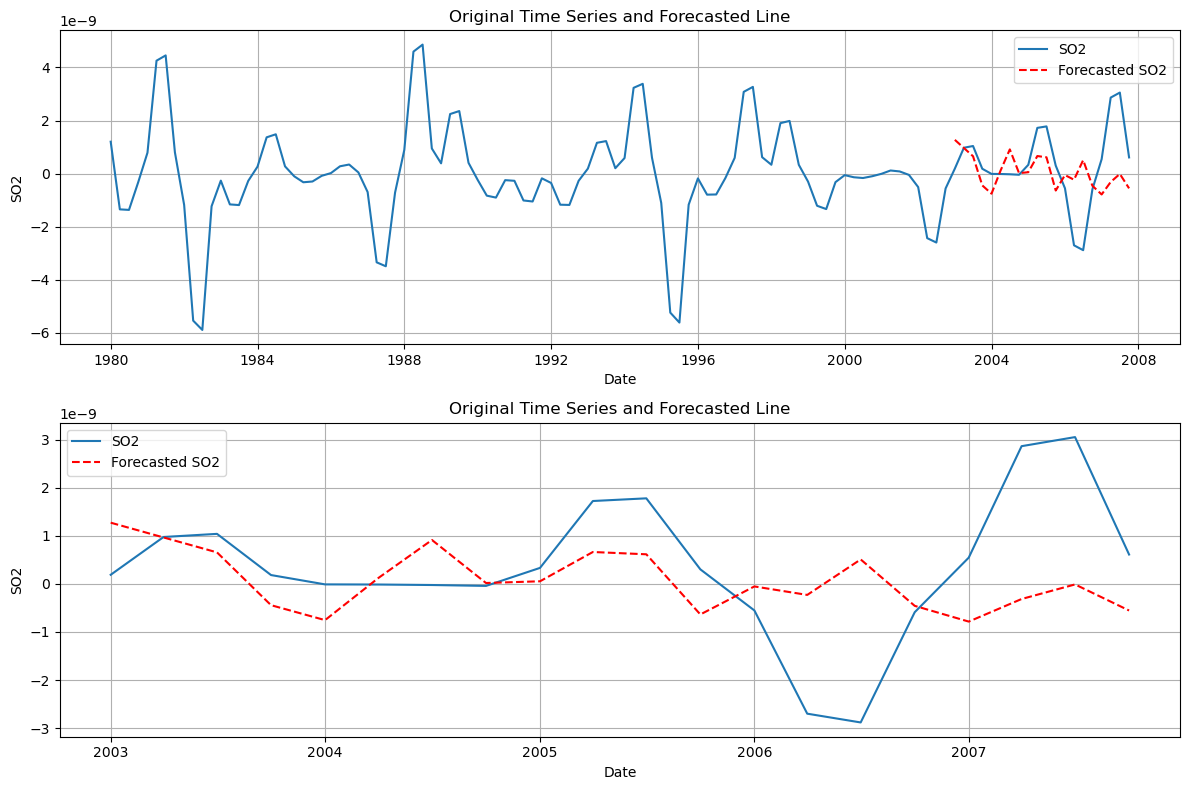

In [22]:
forecast_data('SARIMAX', merged_df, cutoff_date = '2015-01-01', truncate = False)
forecast_data('SARIMAX', merged_df, cutoff_date = '2003-01-01', truncate = True)

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.p

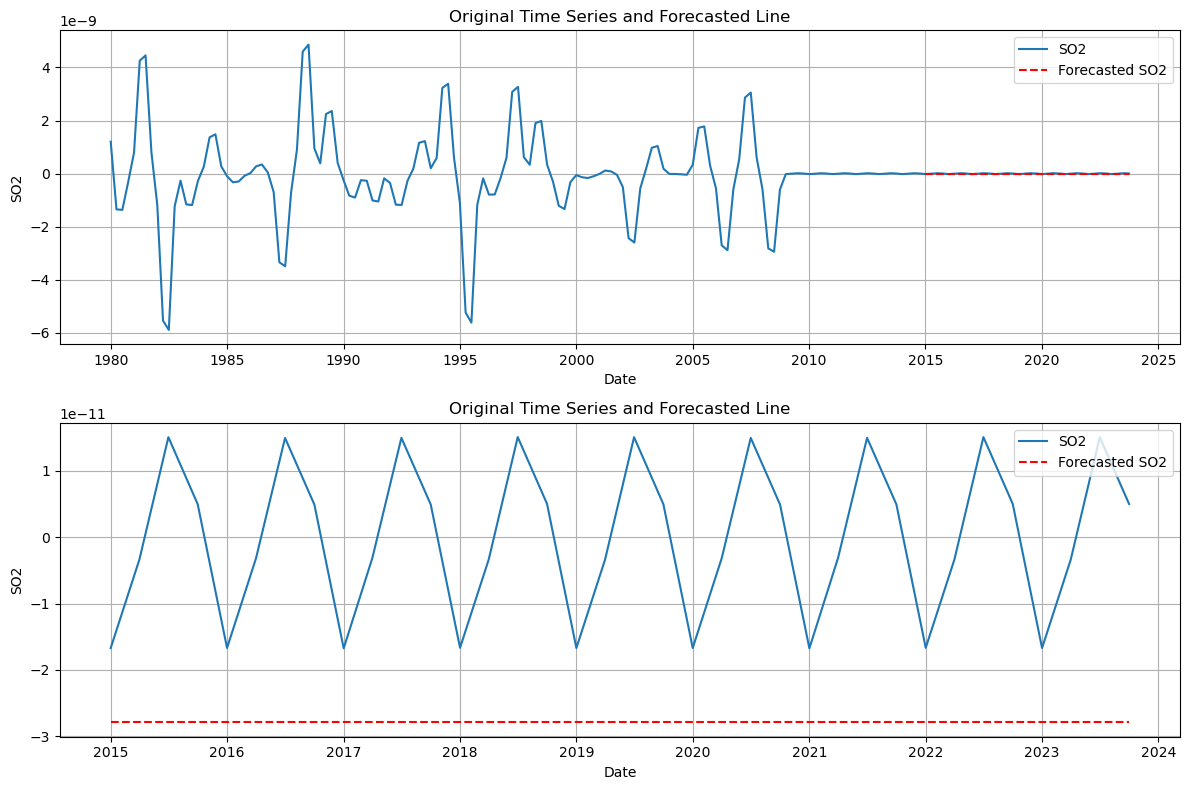

/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/kevinmotia/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.p

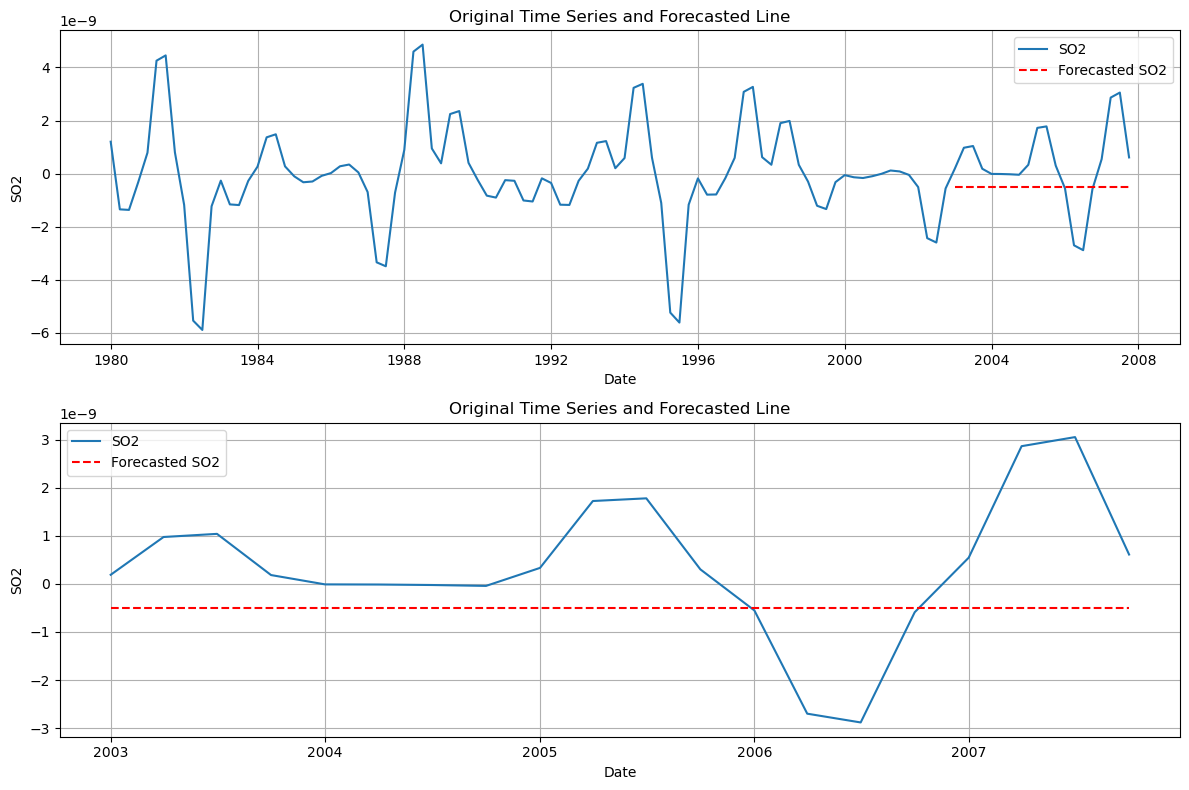

In [20]:
forecast_data('SES', merged_df, cutoff_date = '2015-01-01', truncate = False)
forecast_data('SES', merged_df, cutoff_date = '2003-01-01', truncate = True)